**Carga de la paqueterias usadas**

In [ ]:
#import Pkg; Pkg.add("CategoricalArrays"); Pkg.add("GLM"); Pkg.add("StatsPlots")
using Random, DataFrames, CategoricalArrays, GLM, Statistics, StatsPlots
Random.seed!(2025)   # semilla para reproducibilidad
n = 300;              # número de observaciones


**Variables simuladas**

In [ ]:
# Variables de entrada
temperatura = rand(28:42, n);          # °C
humedad = rand(15:60, n);              # %
viento = rand(5:40, n);                # km/h
vegetacion = rand(["alta", "media", "baja"], n);  # categórica

**Definicion del riesgo**

In [ ]:
riesgo = [
    (t > 35 && v > 25 && h < 25) || (veg == "alta" && rand() < 0.2) ? 1 : 0
    for (t,h,v,veg) in zip(temperatura, humedad, viento, vegetacion)
];

**Dataframe**

In [ ]:
df = DataFrame(
    temperatura = temperatura,
    humedad = humedad,
    viento = viento,
    vegetacion = categorical(vegetacion),
    riesgo = riesgo
);
println("Primeras filas del dataset sintético:")
first(df, 10)

Primeras filas del dataset sintético:


Row,temperatura,humedad,viento,vegetacion,riesgo
,Int64,Int64,Int64,Cat…,Int64
1,31,32,21,baja,0
2,30,57,39,media,0
3,29,30,24,alta,0
4,30,51,9,baja,0
5,39,16,29,baja,1
6,40,43,8,alta,0
7,29,53,17,baja,0
8,30,25,20,baja,0
9,29,25,22,media,0


**Ajustar modelo de regresion logistica**

In [ ]:
modelo_logit = glm(
    @formula(riesgo ~ temperatura + humedad + viento + vegetacion),
    df,
    Binomial(),
    LogitLink()
);

println("Resumen del modelo logístico:")
println(coeftable(modelo_logit))


Resumen del modelo logístico:
───────────────────────────────────────────────────────────────────────────────────
                        Coef.  Std. Error      z  Pr(>|z|)    Lower 95%   Upper 95%
───────────────────────────────────────────────────────────────────────────────────
(Intercept)        -6.16953     2.21545    -2.78    0.0054  -10.5117     -1.82733
temperatura         0.160071    0.0582129   2.75    0.0060    0.0459756   0.274166
humedad            -0.0781859   0.0205986  -3.80    0.0001   -0.118558   -0.0378134
viento              0.0765397   0.0223697   3.42    0.0006    0.0326959   0.120384
vegetacion: baja   -1.91572     0.545079   -3.51    0.0004   -2.98406    -0.847389
vegetacion: media  -3.04168     0.827069   -3.68    0.0002   -4.6627     -1.42065
───────────────────────────────────────────────────────────────────────────────────


**Funcion para medir la precision del modelo**

In [ ]:
function metricas(ŷ, y)
    TP = sum((ŷ .== 1) .& (y .== 1)) #Detecto riesgo de incendio
    TN = sum((ŷ .== 0) .& (y .== 0)) #No Detecto
    FP = sum((ŷ .== 1) .& (y .== 0)) #Falso positivo
    FN = sum((ŷ .== 0) .& (y .== 1)) #Falso Negativo

    accuracy = (TP + TN) / length(y)
    sensibilidad = TP / (TP + FN + 1e-9)  #Ignorar alarmas
    especificidad = TN / (TN + FP + 1e-9) #Falsas alarmas

    return accuracy, sensibilidad, especificidad
end

metricas (generic function with 1 method)

**Aplicacion de Bootstrap al modelo**

In [ ]:
function bootstrap_metricas(df; B=200)
    n = nrow(df)
    accs, senss, esps = Float64[], Float64[], Float64[]

    for b in 1:B
        idx = rand(1:n, n)  # remuestreo con reemplazo
        df_boot = df[idx, :]

        # Re-entrenar modelo logístico
        modelo = glm(
            @formula(riesgo ~ temperatura + humedad + viento + vegetacion),
            df_boot, Binomial(), LogitLink()
        )

        # Predicciones sobre el dataset original
        ŷ = predict(modelo, df) .> 0.5
        acc, sens, esp = metricas(ŷ, df.riesgo)

        push!(accs, acc)
        push!(senss, sens)
        push!(esps, esp)
    end
    return accs, senss, esps
end

accs, senss, esps = bootstrap_metricas(df, B=200);

println("Resultados Bootstrap (200 remuestreos):")
println("Accuracy medio: ", round(mean(accs), digits=3),
        " | IC95%: ", quantile(accs, [0.025, 0.975]))
println("Sensibilidad media: ", round(mean(senss), digits=3),
        " | IC95%: ", quantile(senss, [0.025, 0.975]))
println("Especificidad media: ", round(mean(esps), digits=3),
        " | IC95%: ", quantile(esps, [0.025, 0.975]))


Resultados Bootstrap (200 remuestreos):
Accuracy medio: 0.9 | IC95%: [0.8866666666666667, 0.91]
Sensibilidad media: 0.212 | IC95%: [0.06896551723900118, 0.37931034481450654]
Especificidad media: 0.974 | IC95%: [0.9483394833913346, 0.9889298892952438]


**Graficas**

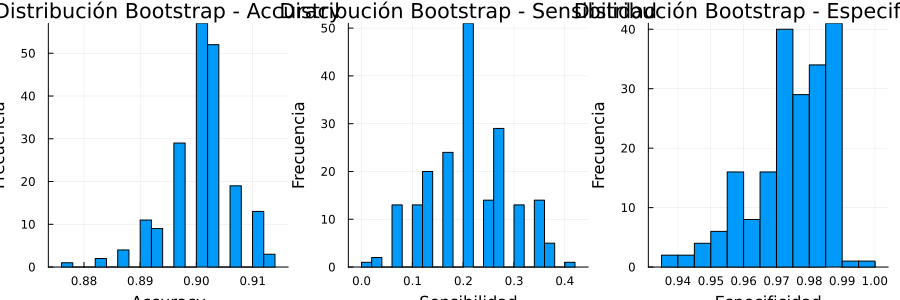

In [ ]:
# Histogramas
p1 = histogram(accs, bins=20, xlabel="Accuracy", ylabel="Frecuencia",
               title="Distribución Bootstrap - Accuracy", legend=false);
p2 = histogram(senss, bins=20, xlabel="Sensibilidad", ylabel="Frecuencia",
               title="Distribución Bootstrap - Sensibilidad", legend=false);
p3 = histogram(esps, bins=20, xlabel="Especificidad", ylabel="Frecuencia",
               title="Distribución Bootstrap - Especificidad", legend=false);

plot(p1, p2, p3, layout=(1,3), size=(900,300))

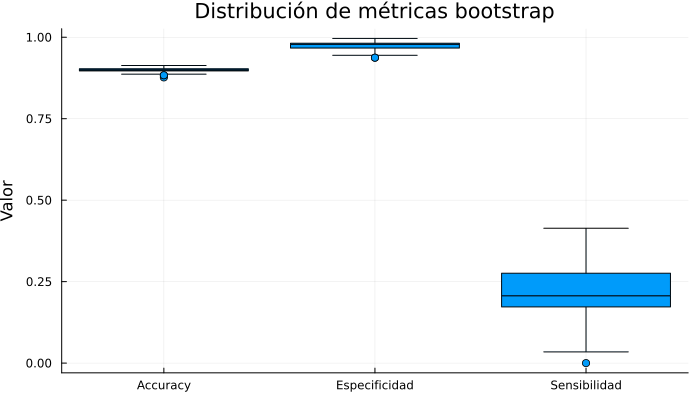

In [ ]:
labels = vcat(fill("Accuracy", length(accs)),
              fill("Sensibilidad", length(senss)),
              fill("Especificidad", length(esps)));

valores = vcat(accs, senss, esps);

boxplot(labels, valores,
        ylabel="Valor",
        title="Distribución de métricas bootstrap",
        legend=false,
        size=(700,400))
